##Exercício de Código | Visualização de dados em python

In [ ]:
import pandas as pd

In [ ]:
dados = pd.read_csv("/content/drive/MyDrive/Progra{m}aria/EXERCÍCIOS_EM_SEQUÊNCIA/Pasta sem título/Cópia de analise_dados - analise_dados.csv")

##Criar um gráfico de barras para visualizar a diferença entre os gêneros

In [ ]:
genero_counts = dados["GENERO"].value_counts()

In [ ]:
import matplotlib.pyplot as plt

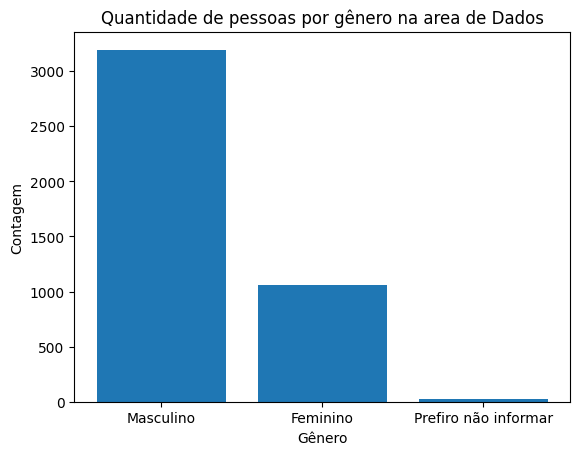

In [ ]:
plt.figure()
plt.bar(height=genero_counts.values, x = genero_counts.index)
plt.title("Quantidade de pessoas por gênero na area de Dados")
plt.xlabel("Gênero")
plt.ylabel("Contagem")
plt.show()

##Outra forma de fazer esse mesmo gráfico, usando outra biblioteca

In [ ]:
import seaborn as sns

/tmp/ipykernel_11726/1059285408.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




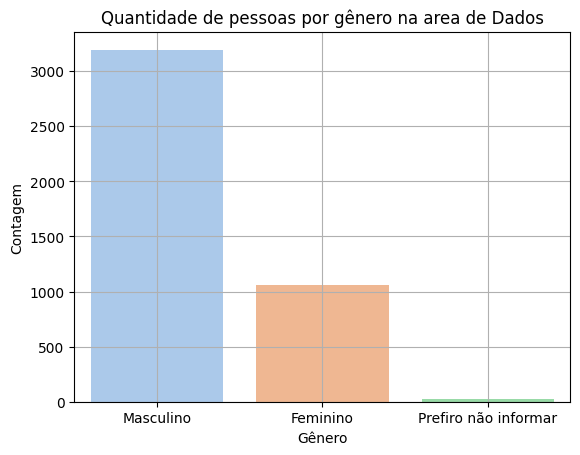

In [ ]:
plt.figure()
sns.countplot(data=dados, x="GENERO", palette="pastel")
plt.title("Quantidade de pessoas por gênero na area de Dados")
plt.xlabel("Gênero")
plt.ylabel("Contagem")
plt.grid(True)
plt.show()

In [ ]:
#Verificar se a média do salário varia de acordo com a idade e criar gráfico.

salario_por_idade = dados.groupby('IDADE')['SALARIO'].apply(lambda x: pd.to_numeric(x, errors='coerce').mean())

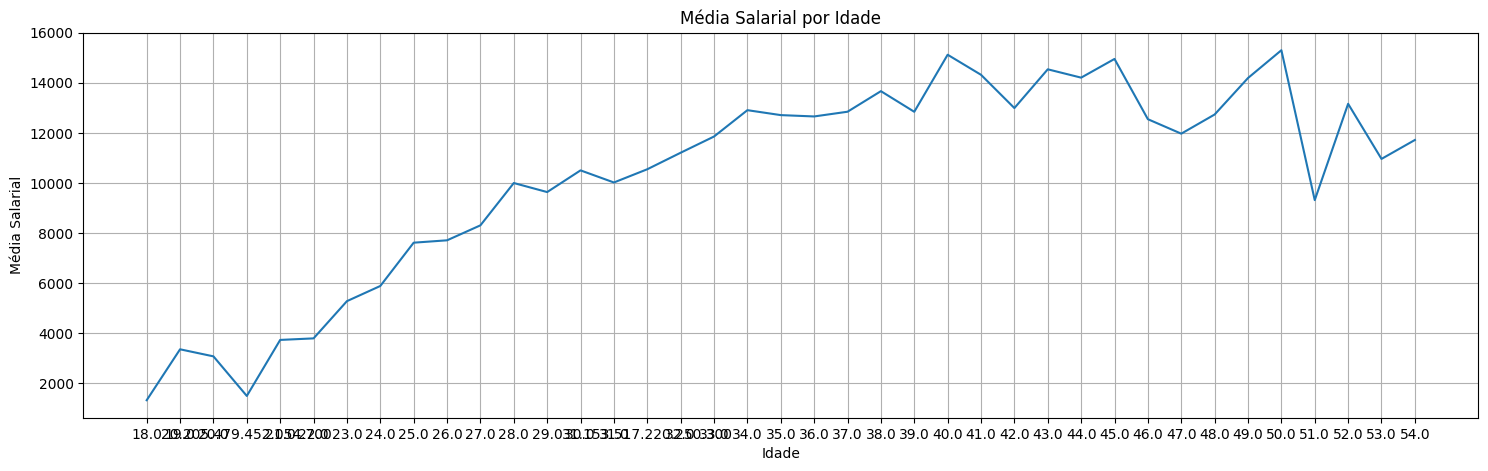

In [ ]:
plt.figure(figsize=(18, 5))
plt.plot(salario_por_idade.index, salario_por_idade.values)
plt.title('Média Salarial por Idade')
plt.xlabel('Idade')
plt.ylabel('Média Salarial')
plt.grid(True)
plt.show()

In [ ]:
#Usando "Ploty" para criar o gráfico em outro estilo
import plotly.express as px

In [ ]:
fig = px.line(salario_por_idade.reset_index(), x='IDADE', y='SALARIO', title='Média Salarial por Idade', markers=True)
fig.show()

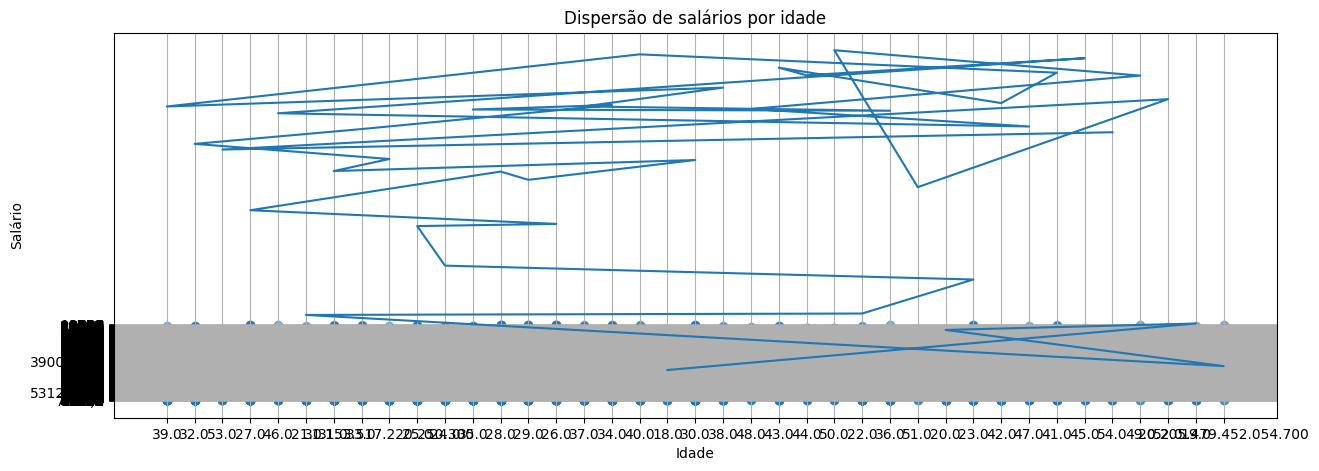

In [ ]:
#Gráfico do tipo scatterplot:
plt.figure(figsize=(15, 5))
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha=0.5)
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.title('Dispersão de salários por idade')
plt.plot(salario_por_idade.index, salario_por_idade.values)
plt.grid(True)
plt.show()

In [ ]:
#Vamos usar "Scatter" para criar o gráfico em outro estilo
fig = px.scatter(dados, x='IDADE', y='SALARIO', title='Dispersão de salários por idade')
fig.show()

##Faça você mesme | Visualização de dados em python



In [63]:
dados = pd.read_csv("/content/drive/MyDrive/Progra{m}aria/EXERCÍCIOS_EM_SEQUÊNCIA/municipios_brasileiros.csv")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

📌 Contar municípios por UF

In [67]:
uf_counts = dados["uf"].value_counts()

📊 Gerar gráfico com matplotlib

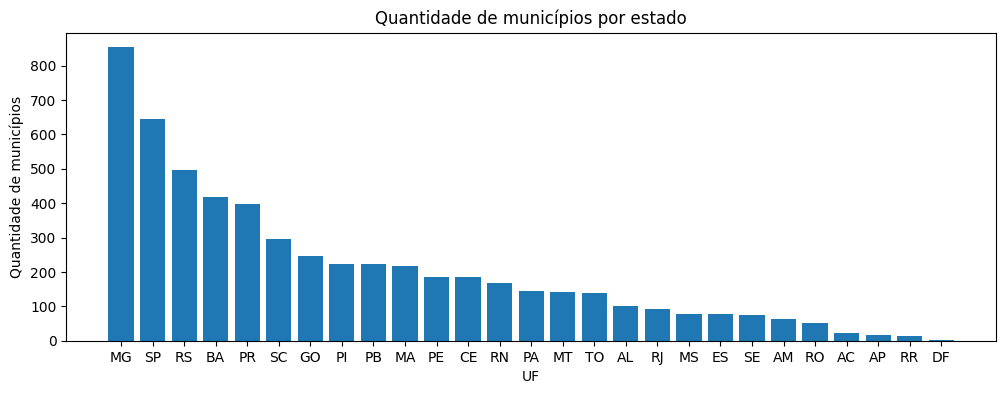

In [69]:
plt.figure(figsize=(12,4))

plt.bar(uf_counts.index, uf_counts.values)

plt.xlabel("UF")
plt.ylabel("Quantidade de municípios")
plt.title("Quantidade de municípios por estado")

plt.show()

✅ MESMO GRÁFICO COM SEABORN

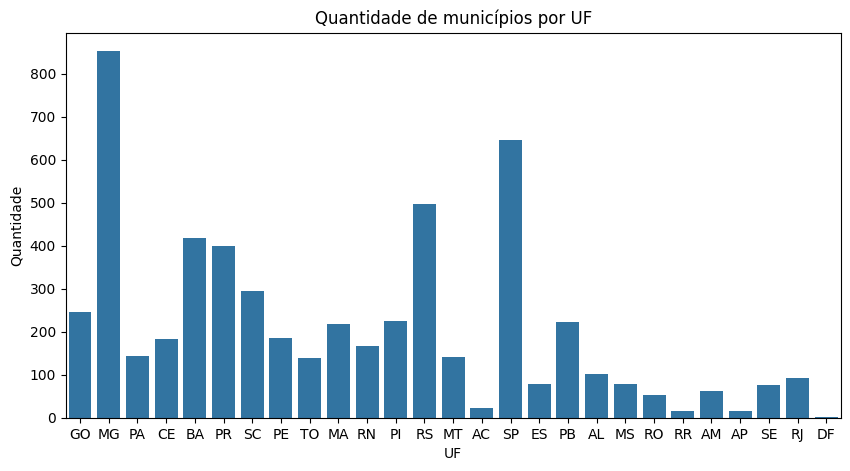

In [71]:
#usando countplot

plt.figure(figsize=(10,5))

sns.countplot(data=dados, x="uf")

plt.xlabel("UF")
plt.ylabel("Quantidade")
plt.title("Quantidade de municípios por UF")

plt.show()

✅ MELHORANDO O VISUAL (ordenando)

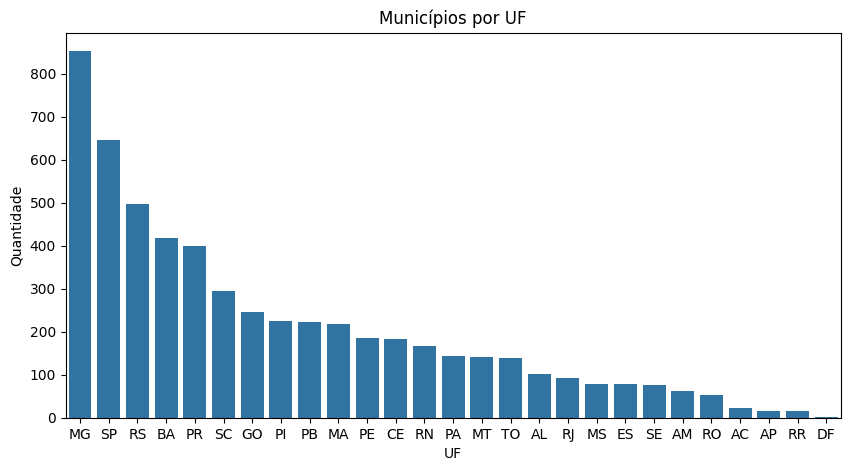

In [73]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=dados,
    x="uf",
    order=dados["uf"].value_counts().index
)

plt.xlabel("UF")
plt.ylabel("Quantidade")
plt.title("Municípios por UF")

plt.show()

✅SCATTERPLOT — Latitude x Longitude

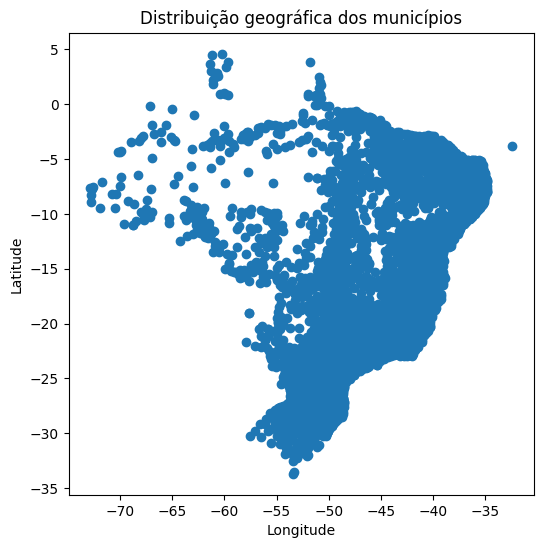

In [79]:
#Aqui vamos visualizar:📍
#distribuição geográfica dos municípios.
#📊 Com matplotlib

plt.figure(figsize=(6,6))

plt.scatter(
    dados["longitude"],
    dados["latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição geográfica dos municípios")

plt.show()


✅ SCATTERPLOT COM SEABORN

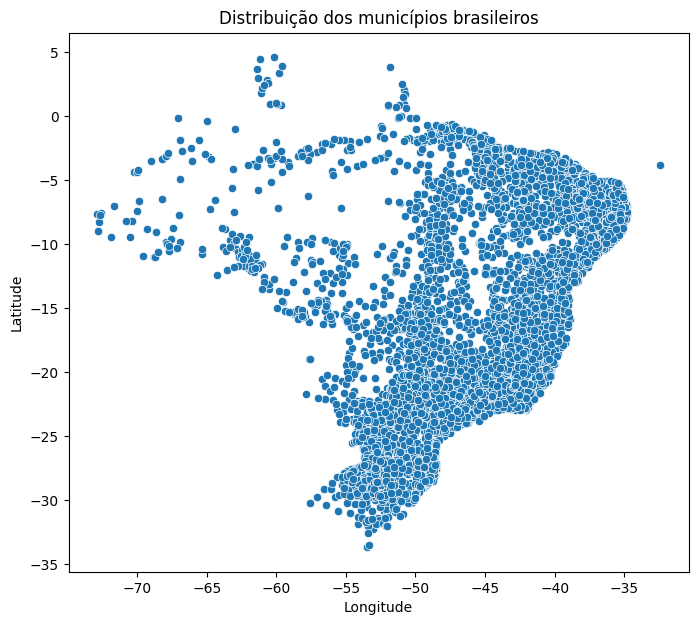

In [81]:
plt.figure(figsize=(8,7))

sns.scatterplot(
    data=dados,
    x="longitude",
    y="latitude"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição dos municípios brasileiros")

plt.show()

✅ PLOTLY — Scatterplot interativo

In [82]:
fig = px.scatter(
    dados,
    x="longitude",
    y="latitude",
    hover_name="nome_municipio",
    color="uf",
    title="Municípios brasileiros"
)

fig.show()

In [83]:
fig = px.scatter_map(
    dados,
    lat="latitude",
    lon="longitude",
    hover_name="nome_municipio",
    hover_data=["uf", "estado", "capital"],
    color="uf",
    zoom=3,
    height=700,
    title="Municípios brasileiros no mapa"
)

fig.show()

Mapa só das capitais

In [85]:
capitais = dados[dados["capital"] == 1]

fig = px.scatter_map(
    capitais,
    lat="latitude",
    lon="longitude",
    hover_name="nome_municipio",
    hover_data=["uf", "estado"],
    color="uf",
    zoom=3,
    height=600,
    title="Capitais brasileiras"
)

fig.show()

Boxplot: latitude por região/UF

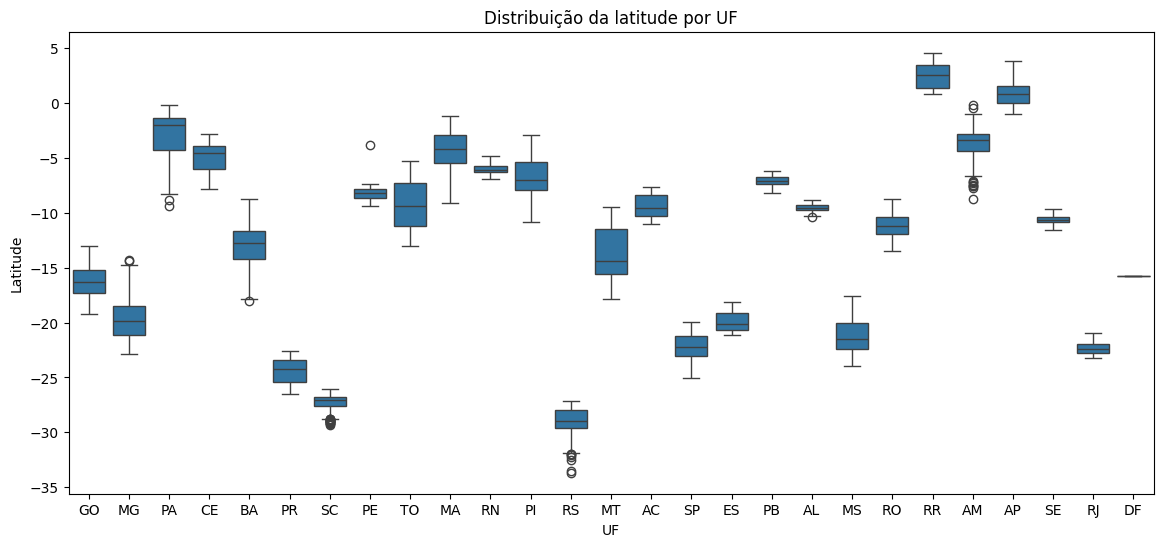

In [86]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=dados,
    x="uf",
    y="latitude"
)

plt.title("Distribuição da latitude por UF")
plt.xlabel("UF")
plt.ylabel("Latitude")
plt.show()

Gráfico animado simples com Plotly

In [89]:
fig = px.scatter(
    dados.sort_values("uf"),
    x="longitude",
    y="latitude",
    animation_frame="uf",
    hover_name="nome_municipio",
    color="uf",
    title="Distribuição dos municípios por UF",
    height=700
)

fig.show()